<a href="https://colab.research.google.com/github/camposgustavo/ANALISE-FILMES-IMDB/blob/main/ANALISE_FILMES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
df = pd.read_csv('/content/imdb_top_1000.csv')
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
df.rename(columns={
    'Poster_Link' : 'Poster_Link',
    'Series_Title':'Titulo_Serie',
    'Released_Year' : 'Ano_Lançamento',
    'Certificate' : 'Classificação',
    'Runtime': 'Duraçao',
    'Genre': 'Genero',
    'IMDB_Rating': 'Nota_IMDB',
    'Overview': 'Sinopse',
    'Meta_score': 'Pontuaçao',
    'Director': 'Diretor',
    'Star1': 'Ator1',
    'Star2': 'Ator2',
    'Star3': 'Ator3',
    'Star4': 'Ator4',
    'No_of_Votes': 'Numero_Votos',
    'Gross': 'Receita_Bruta'
}, inplace = True)

In [ ]:
df.head()

,Poster_Link,Titulo_Serie,Ano_Lançamento,Classificação,Duraçao,Genero,Nota_IMDB,Sinopse,Pontuaçao,Diretor,Ator1,Ator2,Ator3,Ator4,Numero_Votos,Receita_Bruta
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Poster_Link     1000 non-null   object 
 1   Titulo_Serie    1000 non-null   object 
 2   Ano_Lançamento  1000 non-null   object 
 3   Classificação   899 non-null    object 
 4   Duraçao         1000 non-null   object 
 5   Genero          1000 non-null   object 
 6   Nota_IMDB       1000 non-null   float64
 7   Sinopse         1000 non-null   object 
 8   Pontuaçao       843 non-null    float64
 9   Diretor         1000 non-null   object 
 10  Ator1           1000 non-null   object 
 11  Ator2           1000 non-null   object 
 12  Ator3           1000 non-null   object 
 13  Ator4           1000 non-null   object 
 14  Numero_Votos    1000 non-null   int64  
 15  Receita_Bruta   831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [ ]:
# valores nulos
df['Pontuaçao'] = df['Pontuaçao'].fillna(df['Pontuaçao'].median())
df['Classificação'] = df['Classificação'].fillna('Unrated')


In [ ]:
# mudando o tipo de dados das colunas
df["Receita_Bruta"] = df['Receita_Bruta'].str.replace(',', '').astype(float)
df['Duraçao'].str.replace('min','').astype(int)
df['Ano_Lançamento']= pd.to_numeric(df['Ano_Lançamento'], errors='coerce')

In [ ]:
#duplicatas
print("Duplicadas: ", df.duplicated().sum())
df= df.drop_duplicates()

Duplicadas:  0


In [ ]:
# criando coluna
df['Genero_Principal'] = df['Genero'].apply(lambda x: x.split(',')[0].strip())

In [ ]:
# quais são os 10 filmes com maiores notas?
df[['Titulo_Serie', 'Nota_IMDB', 'Ano_Lançamento']].sort_values(by='Nota_IMDB', ascending=False).head(10)

,Titulo_Serie,Nota_IMDB,Ano_Lançamento
0,The Shawshank Redemption,9.3,1994.0
1,The Godfather,9.2,1972.0
4,12 Angry Men,9.0,1957.0
2,The Dark Knight,9.0,2008.0
3,The Godfather: Part II,9.0,1974.0
5,The Lord of the Rings: The Return of the King,8.9,2003.0
7,Schindler's List,8.9,1993.0
6,Pulp Fiction,8.9,1994.0
8,Inception,8.8,2010.0
12,"Il buono, il brutto, il cattivo",8.8,1966.0


In [ ]:
df['Diretor'].value_counts().head(10)

,count
Diretor,
Alfred Hitchcock,14
Steven Spielberg,13
Hayao Miyazaki,11
Akira Kurosawa,10
Martin Scorsese,10
Woody Allen,9
Stanley Kubrick,9
Billy Wilder,9
Clint Eastwood,8


In [ ]:
df['Genero_Principal'].value_counts().head(10)

,count
Genero_Principal,
Drama,289
Action,172
Comedy,155
Crime,107
Biography,88
Animation,82
Adventure,72
Mystery,12
Horror,11


In [ ]:
Sumario_Genero = df.groupby('Genero_Principal').agg(qtd_filmes=('Titulo_Serie', 'count'), faturamento_medio=('Receita_Bruta', 'mean'), nota_imdb_media=('Nota_IMDB', 'mean'), metacritic_medio=('Pontuaçao', 'mean')).sort_values(by='faturamento_medio', ascending=False)

In [ ]:
Sumario_Genero.head(10)

,qtd_filmes,faturamento_medio,nota_imdb_media,metacritic_medio
Genero_Principal,,,,
Family,2,2.195553e+08,7.800000,79.000000
Action,172,1.419631e+08,7.949419,74.360465
Animation,82,1.279675e+08,7.930488,80.914634
Adventure,72,8.645499e+07,7.937500,78.500000
Horror,11,7.358577e+07,7.909091,80.000000
Biography,88,6.012873e+07,7.938636,76.522727
Drama,289,3.867728e+07,7.957439,79.584775
Crime,107,3.419123e+07,8.016822,77.439252
Comedy,155,3.253759e+07,7.901290,78.774194


/tmp/ipykernel_1774/1499117871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( #barras


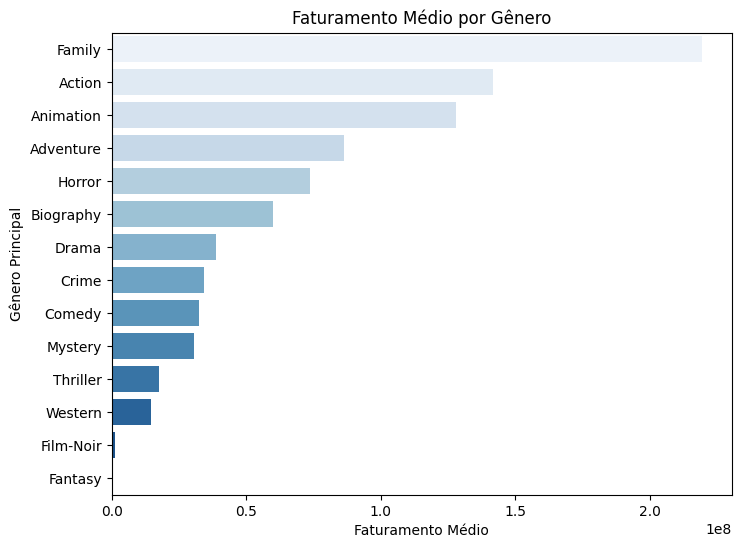

In [ ]:
#Faturamento Médio por Gênero
plt.figure(figsize=(8, 6))

sns.barplot( #barras
    data=Sumario_Genero.reset_index(),
    x='faturamento_medio', #coluna
    y='Genero_Principal',
    legend = False,
    palette='Blues'
)
plt.title("Faturamento Médio por Gênero")
plt.xlabel("Faturamento Médio")
plt.ylabel("Gênero Principal")

plt.show()


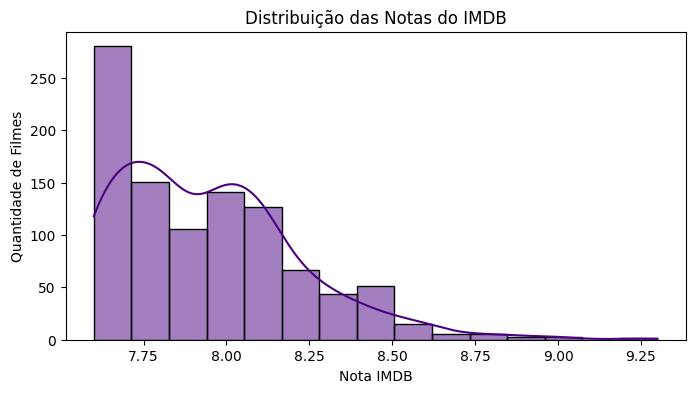

In [ ]:
#Distribuição das Notas do IMDB - Histograma
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x="Nota_IMDB",
    bins=15, #quantidade de barras
    kde=True,
    color="indigo"
)

plt.title('Distribuição das Notas do IMDB')
plt.xlabel('Nota IMDB')
plt.ylabel('Quantidade de Filmes')
plt.show()

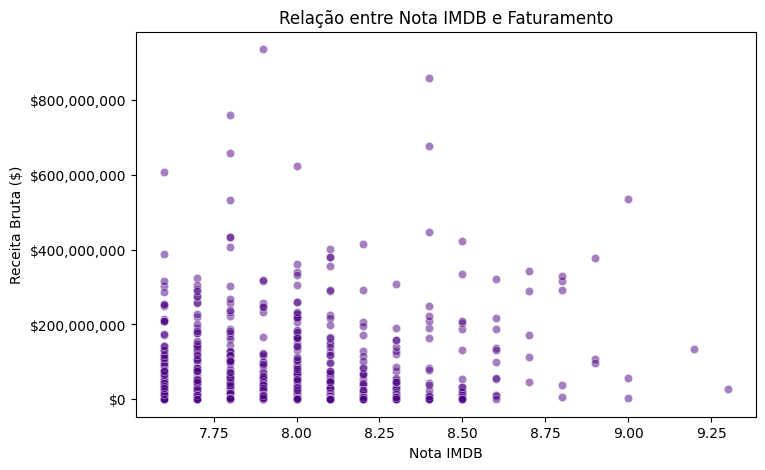

In [ ]:
#Relação entre Nota IMDB e faturamento
import matplotlib.ticker as ticker #formatar o valor
plt.figure (figsize=(8,5))

sns.scatterplot( #dispersão
    data = df,
    x="Nota_IMDB",
    y="Receita_Bruta",
    alpha=0.5,
    color='indigo'
)

plt.title("Relação entre Nota IMDB e Faturamento")
plt.xlabel("Nota IMDB")
plt.ylabel('Receita Bruta ($)')

formatter = ticker.StrMethodFormatter('${x:,.0f}') # como formatar/ler cada valor
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()


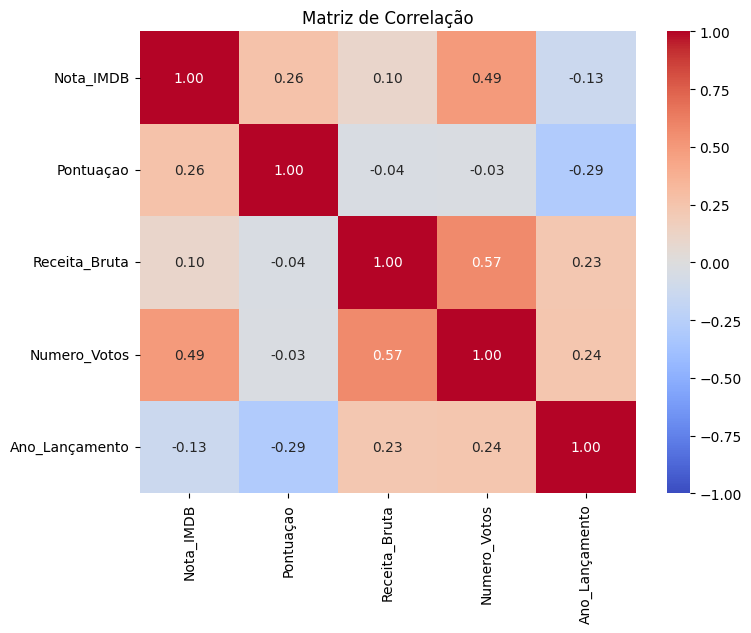

In [ ]:

# Matriz de Correlação
plt.figure(figsize=(8,6))

colunas_num = ['Nota_IMDB', 'Pontuaçao','Receita_Bruta', 'Numero_Votos', 'Ano_Lançamento' ]
matriz_corr = df[colunas_num].corr()
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Matriz de Correlação")
plt.show()